# 0. Project Overview

**Credit Risk Prediction**

**ID/X Partners x Rakamin Academy**

### Project Objective

Pada project ini, saya membangun model machine learning untuk memprediksi risiko kredit berdasarkan data historis pinjaman.

Tujuan utama dari project ini adalah memahami karakteristik pinjaman yang memiliki risiko kredit lebih tinggi serta membangun model klasifikasi yang dapat membantu perusahaan lending dalam melakukan risk assessment.

### Methodology

Proses pengerjaan dilakukan menggunakan tahapan Data Science berikut:

1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preparation
4. Data Modelling
5. Evaluation
6. Conclusion and Recommendation

### Models

Dua algoritma machine learning digunakan dalam project ini:

- Logistic Regression
- Random Forest

Logistic Regression digunakan sebagai salah satu model utama karena sesuai untuk permasalahan binary classification dan juga menjadi salah satu algoritma yang dipersyaratkan dalam final task.

Random Forest digunakan sebagai model pembanding untuk melihat apakah model berbasis decision tree dapat memberikan performa yang lebih baik.

# 1. Data Understanding

Tahap pertama dilakukan untuk memahami dataset yang diberikan sebelum masuk ke proses analisis dan modelling.

Pada tahap ini saya akan melihat:

- ukuran dataset
- beberapa contoh data
- tipe data setiap kolom
- missing values
- duplicate data
- distribusi status pinjaman
- variabel yang akan digunakan sebagai target

Tahap ini penting agar proses analisis berikutnya dilakukan berdasarkan pemahaman terhadap data yang tersedia.

## 1.1. Import Libraries

In [11]:
# Import libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Untuk hasil yang lebih konsisten
RANDOM_STATE = 42

# Agar seluruh kolom dapat ditampilkan
pd.set_option('display.max_columns', None)

# Style visualisasi
sns.set_style('whitegrid')

print("Libraries successfully imported.")

Libraries successfully imported.


## 1.2. Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
df = pd.read_csv('/content/drive/MyDrive/GColab/loan_data_2007_2014.csv')

## 1.3. Dataset Overview

In [13]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.tail()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,C2,Financial Advisor,4 years,MORTGAGE,110000.0,Source Verified,Jan-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,773xx,TX,19.85,0.0,Apr-03,2.0,NaN,NaN,18.0,0.0,23208,77.6,36.0,w,12574.00,12574.00,10383.360000,10383.36,5826.00,4557.36,0.0,0.0,0.0,Jan-16,432.64,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,294998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,D5,Chief of Interpretation (Park Ranger),10+ years,MORTGAGE,78000.0,Verified,Jan-14,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,377xx,TN,18.45,0.0,Jun-97,5.0,NaN,116.0,18.0,1.0,18238,46.3,30.0,f,0.00,0.00,4677.920000,4677.92,1837.04,2840.88,0.0,0.0,0.0,Dec-14,17.50,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,221830.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,D1,patrol,7 years,MORTGAGE,46000.0,Verified,Jan-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/06/13 > I am going to c...,debt_consolidation,Debt consolidation,458xx,OH,25.65,0.0,Dec-01,2.0,65.0,NaN,18.0,0.0,6688,51.1,43.0,f,14428.31,14428.31,12343.980000,12343.98,6271.69,6072.29,0.0,0.0,0.0,Jan-16,514.34,Feb-16,Dec-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,73598.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,A4,Server Engineer Lead,3 years,OWN,83000.0,Verified,Jan-14,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,Credit card refinancing,913xx,CA,5.39,3.0,Feb-03,1.0,13.0,NaN,21.0,0.0,11404,21.5,27.0,w,0.00,0.00,2126.579838,2126.58,2000.00,126.58,0.0,0.0,0.0,Dec-14,1500.68,NaN,Apr-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,591610.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN
466284,466284,9199665,11061576,10000,10000,9975.0,36 months,19.20,367.58,D,D3,NaN,10+ years,MORTGAGE,46000.0,Verified,Jan-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/04/13 > I will like a l...,other,Other,950xx,CA,22.78,1.0,Feb-00,0.0,9.0,NaN,6.0,0.0,11325,70.8,22.0,f,3984.38,3974.41,8821.620000,8799.57,6015.62,2806.00,0.0,0.0,0.0,Jan-16,367.58,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,57477.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16000.0,NaN,NaN,NaN


In [16]:
# Melihat ukuran dataset

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 466285
Jumlah kolom : 75


## 1.4. Data Types

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [18]:
df.dtypes.value_counts()

,count
float64,46
object,22
int64,7


## 1.5. Missing Values

In [19]:
# Menghitung missing values

missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data.sort_values(
    by='Missing Values',
    ascending=False
)

missing_data.head(20)

,Missing Values,Percentage
max_bal_bc,466285,100.00
open_rv_24m,466285,100.00
inq_fi,466285,100.00
open_rv_12m,466285,100.00
il_util,466285,100.00
mths_since_rcnt_il,466285,100.00
total_bal_il,466285,100.00
open_il_24m,466285,100.00
open_il_12m,466285,100.00
open_il_6m,466285,100.00


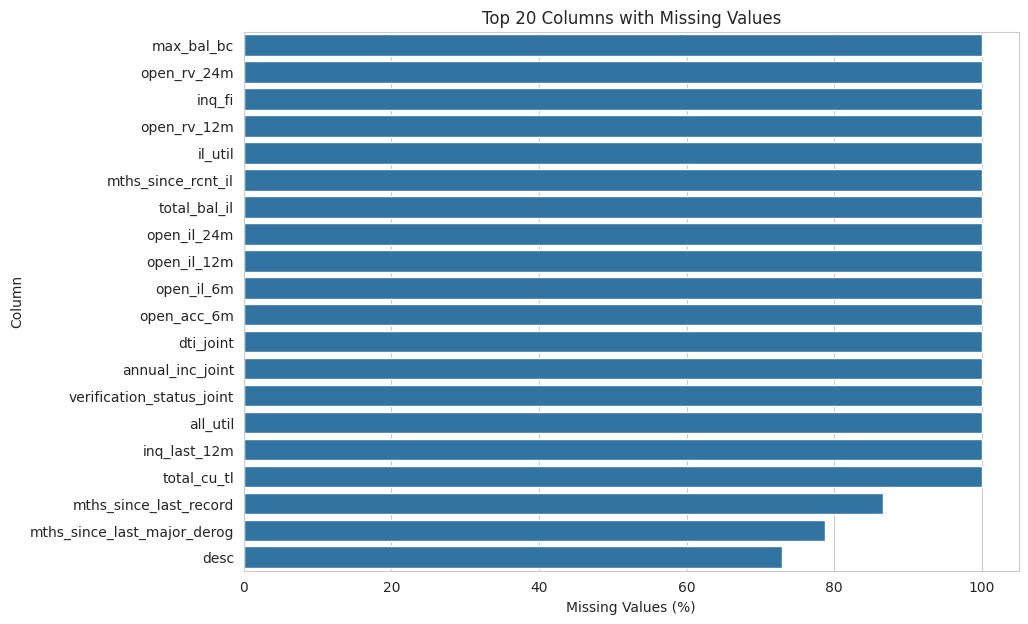

In [20]:
# Visualisasi 20 kolom dengan missing values terbanyak

missing_plot = (
    missing_data[missing_data['Missing Values'] > 0]
    .head(20)
    .reset_index()
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=missing_plot,
    x='Percentage',
    y='index'
)

plt.title('Top 20 Columns with Missing Values')
plt.xlabel('Missing Values (%)')
plt.ylabel('Column')

plt.show()

## 1.6. Duplicate Data

In [21]:
# Mengecek duplicate

duplicate_count = df.duplicated().sum()

print("Jumlah duplicate rows:", duplicate_count)

Jumlah duplicate rows: 0


## 1.7. Loan Status Distribution
Kolom `loan_status` digunakan untuk melihat bagaimana status pembayaran pinjaman pada dataset.

Karena tujuan project adalah memprediksi credit risk, kolom ini akan menjadi dasar dalam menentukan target variable.

In [22]:
# Melihat distribusi loan status

loan_status_count = df['loan_status'].value_counts()

display(loan_status_count)

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


In [23]:
# Persentase setiap loan status

loan_status_percentage = (
    df['loan_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(loan_status_percentage)

,proportion
loan_status,
Current,48.09
Fully Paid,39.62
Charged Off,9.11
Late (31-120 days),1.48
In Grace Period,0.67
Does not meet the credit policy. Status:Fully Paid,0.43
Late (16-30 days),0.26
Default,0.18
Does not meet the credit policy. Status:Charged Off,0.16


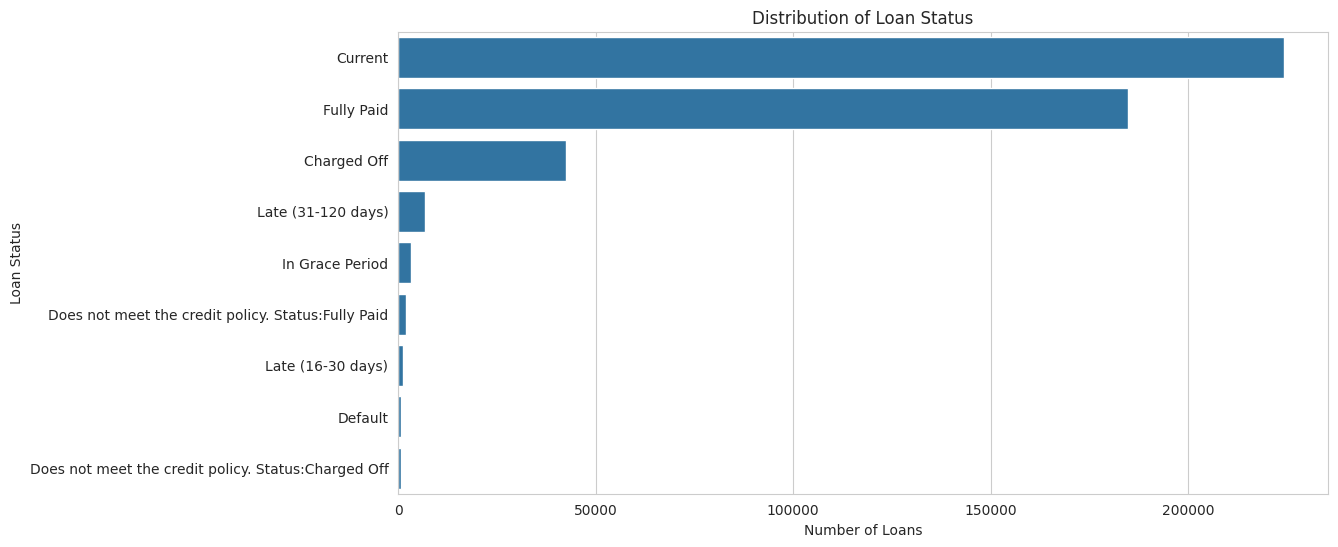

In [24]:
# Visualisasi loan status

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='loan_status',
    order=df['loan_status'].value_counts().index
)

plt.title('Distribution of Loan Status')
plt.xlabel('Number of Loans')
plt.ylabel('Loan Status')

plt.show()

## 1.8. Target Variable

Untuk membangun model binary classification, `loan_status` akan diubah menjadi dua kategori:

### GOOD = 0

- Fully Paid
- Does not meet the credit policy. Status:Fully Paid

### BAD = 1

- Charged Off
- Default
- Does not meet the credit policy. Status:Charged Off

Status seperti `Current`, `Late`, dan `In Grace Period` tidak digunakan dalam modelling karena belum menunjukkan final outcome kredit yang dapat dibandingkan secara langsung dengan Fully Paid atau Charged Off.

Pendekatan ini digunakan agar model mempelajari perbedaan antara pinjaman yang memiliki outcome baik dan pinjaman yang memiliki outcome bermasalah.


In [25]:
# Menentukan status GOOD dan BAD

good_status = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'
]

bad_status = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

# Membuat dataset untuk modelling

df_model = df[
    df['loan_status'].isin(good_status + bad_status)
].copy()

# Membuat target binary

df_model['credit_risk'] = np.where(
    df_model['loan_status'].isin(bad_status),
    1,
    0
)

print("Jumlah data awal :", len(df))
print("Jumlah data modelling :", len(df_model))

Jumlah data awal : 466285
Jumlah data modelling : 230795


In [28]:
# Melihat distribusi target

target_distribution = (
    df_model['credit_risk']
    .value_counts()
    .sort_index()
)

display(target_distribution)

,count
credit_risk,
0,186727
1,44068


In [29]:
# Persentase target

target_percentage = (
    df_model['credit_risk']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(target_percentage)

,proportion
credit_risk,
0,80.91
1,19.09


# 2. Exploratory Data Analysis (EDA)

Setelah memahami struktur dataset dan menentukan target, tahap berikutnya adalah melakukan Exploratory Data Analysis (EDA).

EDA dilakukan untuk melihat karakteristik borrower dan loan serta mencari pola yang mungkin berhubungan dengan credit risk.

Analisis dilakukan menggunakan:

- analisis univariat
- analisis bivariat
- visualisasi
- statistik deskriptif
- correlation analysis

## 2.1. Analisis Univariat

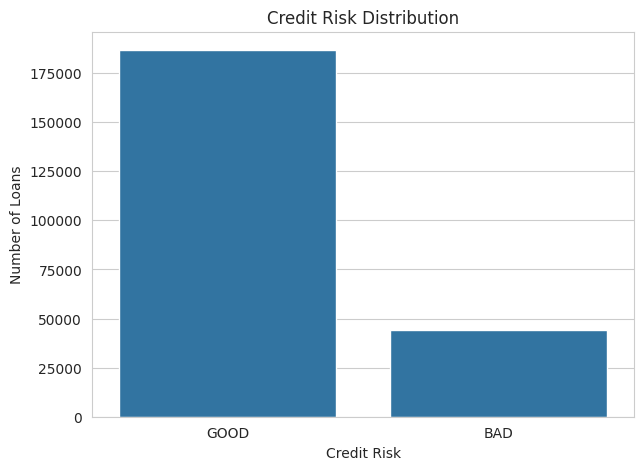

In [70]:
# Target Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_model,
    x='credit_risk'
)

plt.title('Credit Risk Distribution')
plt.xlabel('Credit Risk')
plt.ylabel('Number of Loans')

plt.xticks(
    [0, 1],
    ['GOOD', 'BAD']
)

plt.show()

**Numerical Variables**

Beberapa variabel numerik seperti loan amount, interest rate, annual income, dan debt-to-income ratio akan dianalisis untuk memahami karakteristik pinjaman dan borrower.

In [31]:
# Statistik deskriptif

df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,230795.0,1.928254e+05,1.332360e+05,0.00,8.040050e+04,181209.00,2.878505e+05,4.662830e+05
id,230795.0,8.269548e+06,9.088253e+06,54734.00,1.350036e+06,5042924.00,1.197543e+07,3.785416e+07
member_id,230795.0,9.361932e+06,9.872429e+06,70473.00,1.588613e+06,6037134.00,1.388762e+07,4.061688e+07
loan_amnt,230795.0,1.341219e+04,8.042976e+03,500.00,7.200000e+03,12000.00,1.800000e+04,3.500000e+04
funded_amnt,230795.0,1.336530e+04,8.017162e+03,500.00,7.200000e+03,12000.00,1.800000e+04,3.500000e+04
funded_amnt_inv,230795.0,1.323291e+04,8.055476e+03,0.00,7.000000e+03,11750.00,1.800000e+04,3.500000e+04
int_rate,230795.0,1.378177e+01,4.368738e+00,5.42,1.074000e+01,13.65,1.640000e+01,2.606000e+01
installment,230795.0,4.151488e+02,2.434729e+02,15.67,2.371900e+02,363.85,5.434400e+02,1.408130e+03
annual_inc,230791.0,7.200431e+04,5.542584e+04,1896.00,4.500000e+04,61920.00,8.600000e+04,7.141778e+06
dti,230795.0,1.634889e+01,7.672534e+00,0.00,1.064000e+01,16.05,2.177000e+01,3.999000e+01


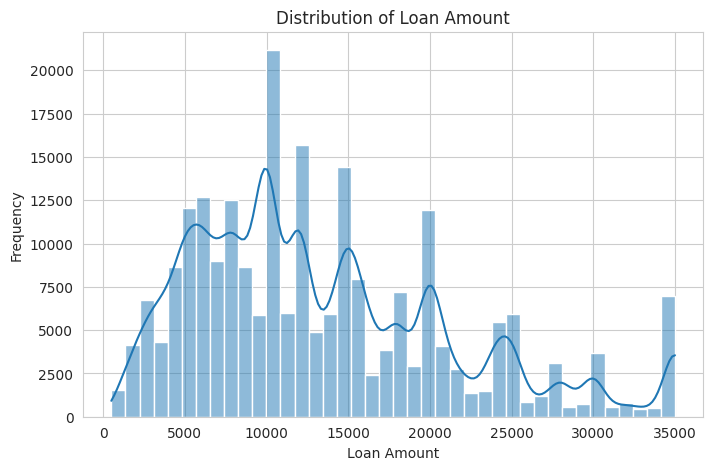

In [34]:
# Loan Amount
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_model,
    x='loan_amnt',
    bins=40,
    kde=True
)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

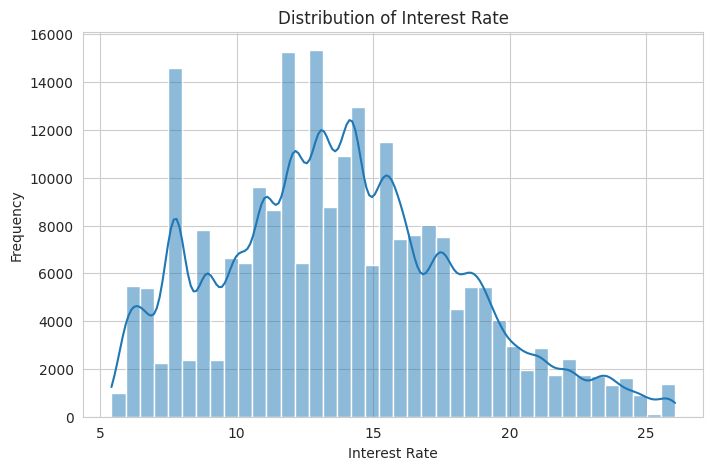

In [35]:
# Interest Rate
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_model,
    x='int_rate',
    bins=40,
    kde=True
)

plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')

plt.show()

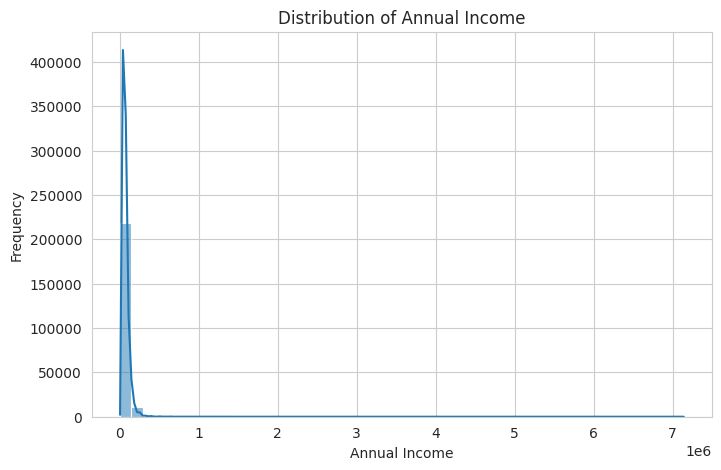

In [36]:
# Annual Income
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_model,
    x='annual_inc',
    bins=50,
    kde=True
)

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

plt.show()

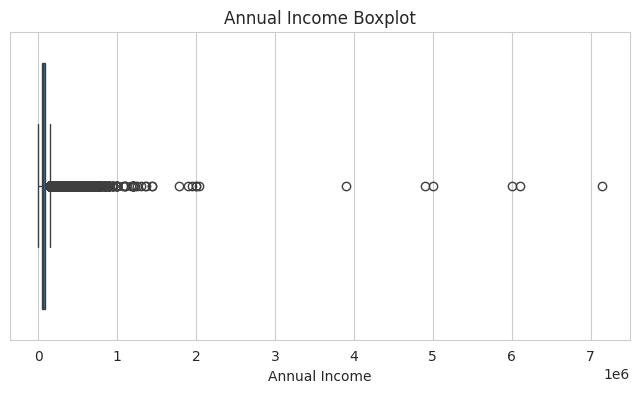

In [37]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_model,
    x='annual_inc'
)

plt.title('Annual Income Boxplot')
plt.xlabel('Annual Income')

plt.show()

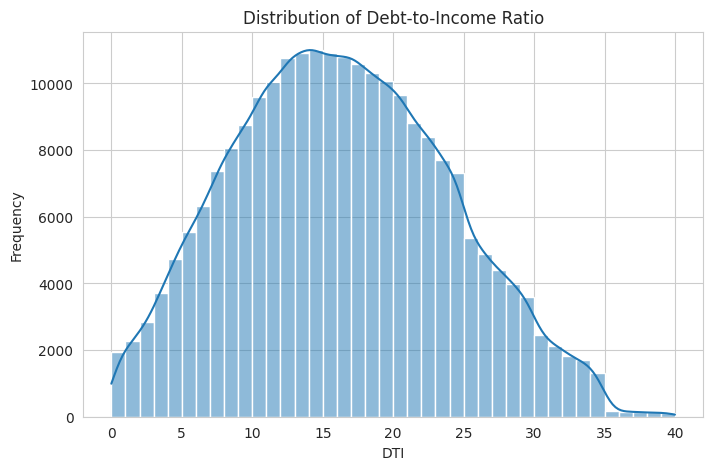

In [38]:
# DTI
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_model,
    x='dti',
    bins=40,
    kde=True
)

plt.title('Distribution of Debt-to-Income Ratio')
plt.xlabel('DTI')
plt.ylabel('Frequency')

plt.show()

**Categorical Variables**

Analisis univariat juga dilakukan pada beberapa variabel kategorikal untuk memahami distribusi masing-masing kategori.

Variabel yang dianalisis meliputi:

- Loan Grade
- Loan Term
- Home Ownership
- Loan Purpose

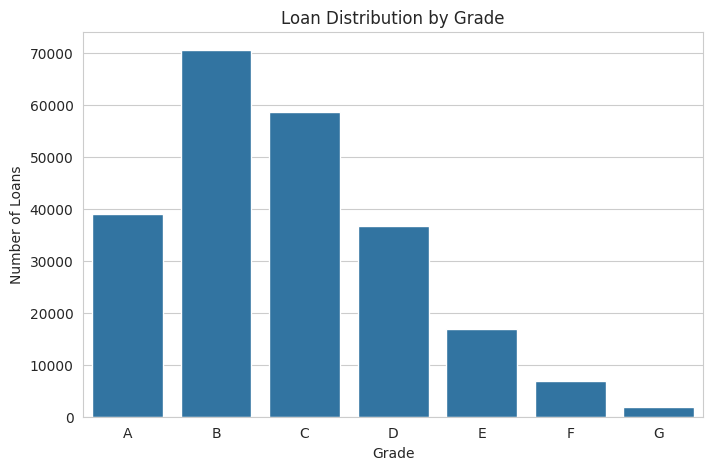

In [39]:
# Loan Grade
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x='grade',
    order=sorted(df_model['grade'].dropna().unique())
)

plt.title('Loan Distribution by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Loans')

plt.show()

In [71]:
grade_risk = (
    df_model
    .groupby('grade')['credit_risk']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    grade_risk.to_frame('BAD Rate (%)')
)

,BAD Rate (%)
grade,
G,43.911638
F,40.820766
E,35.396872
D,27.645618
C,21.026507
B,13.297556
A,6.558425


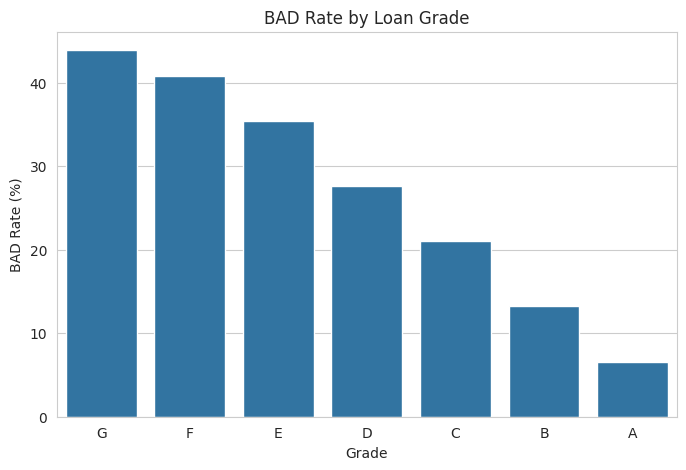

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=grade_risk.index,
    y=grade_risk.values
)

plt.title('BAD Rate by Loan Grade')
plt.xlabel('Grade')
plt.ylabel('BAD Rate (%)')

plt.show()

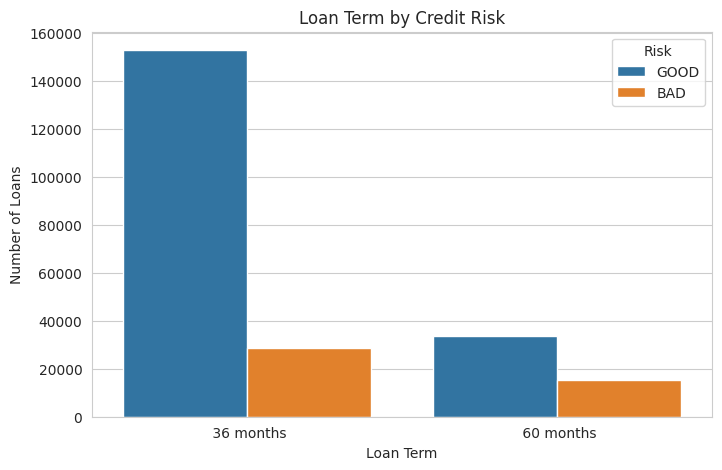

In [72]:
# Loan Term
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x='term',
    hue='credit_risk'
)

plt.title('Loan Term by Credit Risk')
plt.xlabel('Loan Term')
plt.ylabel('Number of Loans')

plt.legend(
    title='Risk',
    labels=['GOOD', 'BAD']
)

plt.show()

In [43]:
term_risk = (
    df_model
    .groupby('term')['credit_risk']
    .mean()
    .mul(100)
)

display(
    term_risk.to_frame('BAD Rate (%)')
)

,BAD Rate (%)
term,
36 months,15.755659
60 months,31.380422


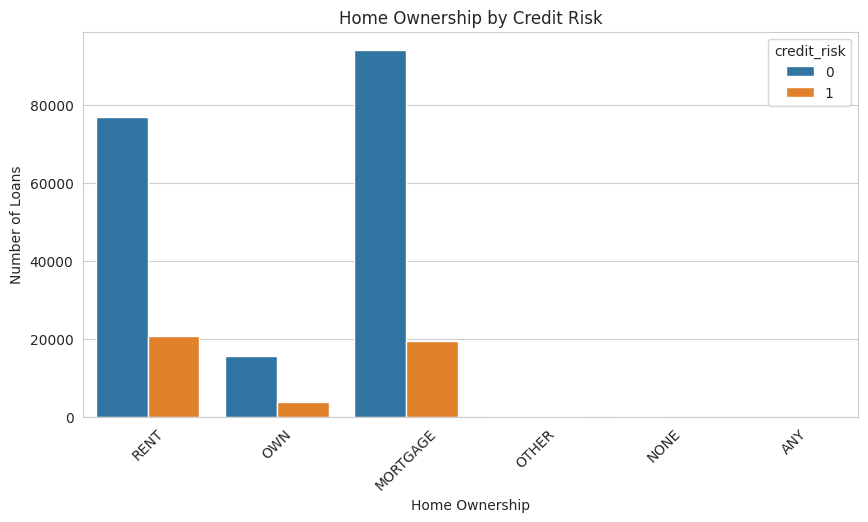

In [73]:
# Home Ownership
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_model,
    x='home_ownership',
    hue='credit_risk'
)

plt.title('Home Ownership by Credit Risk')
plt.xlabel('Home Ownership')
plt.ylabel('Number of Loans')

plt.xticks(rotation=45)

plt.show()

In [74]:
# Loan Purpose
purpose_risk = (
    df_model
    .groupby('purpose')['credit_risk']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    purpose_risk.to_frame('BAD Rate (%)')
)

,BAD Rate (%)
purpose,
small_business,30.193133
moving,22.390481
other,22.077727
medical,20.923193
educational,20.853081
renewable_energy,20.472441
debt_consolidation,19.915621
house,18.945964
vacation,18.500350


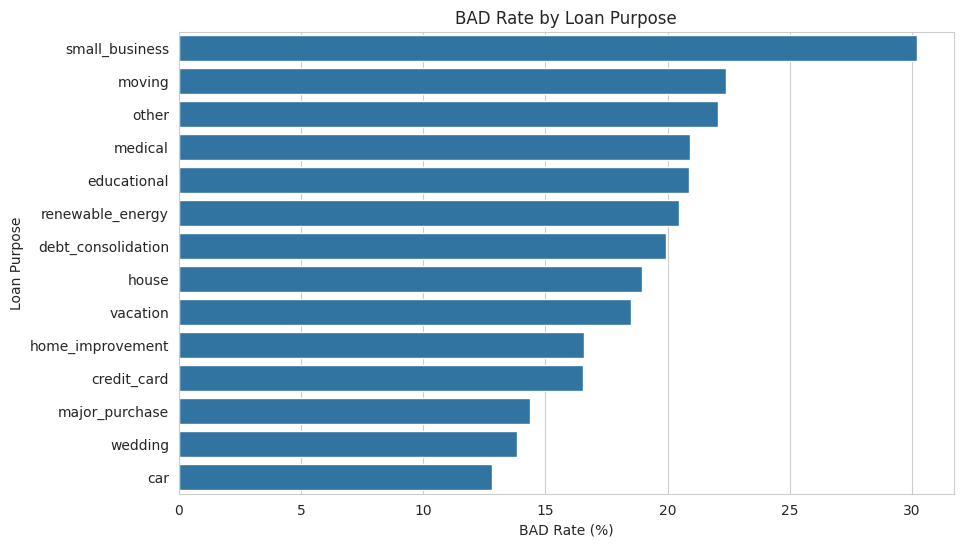

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=purpose_risk.values,
    y=purpose_risk.index
)

plt.title('BAD Rate by Loan Purpose')
plt.xlabel('BAD Rate (%)')
plt.ylabel('Loan Purpose')

plt.show()

## 2.2. Analisis Bivariat

Analisis bivariat dilakukan untuk melihat hubungan antara variabel dengan target variable, yaitu `credit_risk`.

Analisis ini dilakukan dengan membandingkan karakteristik borrower dan loan antara kelompok GOOD dan BAD.

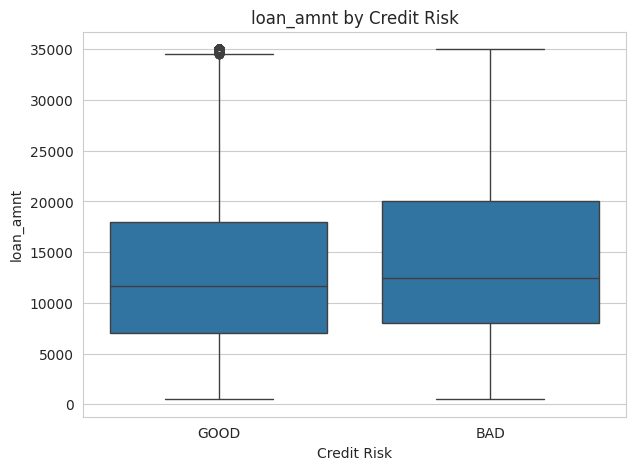

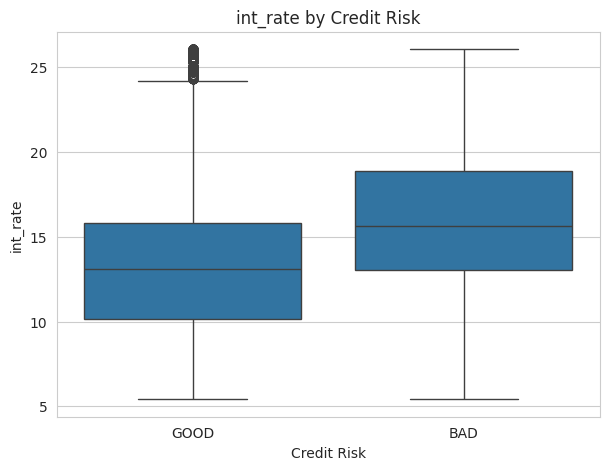

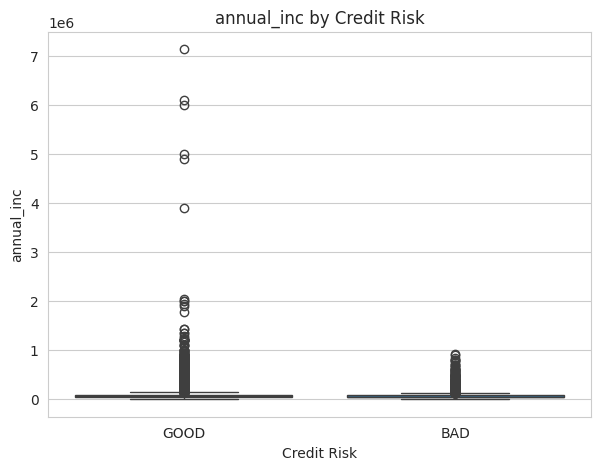

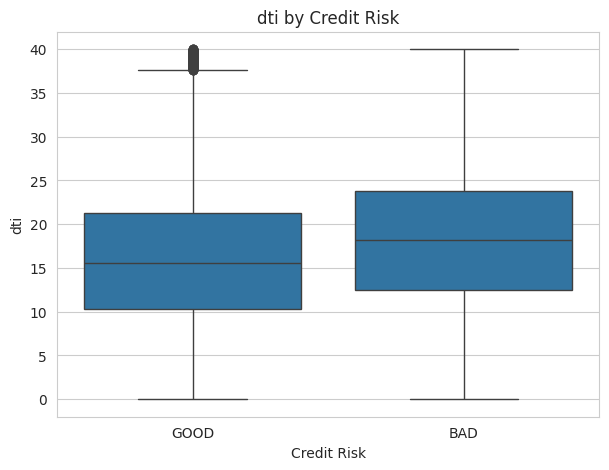

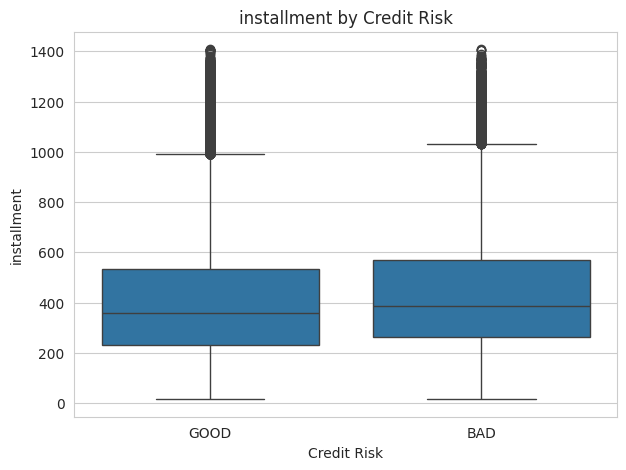

In [75]:
# Numerical Variables vs Credit Risk
numeric_eda = [
    'loan_amnt',
    'int_rate',
    'annual_inc',
    'dti',
    'installment'
]

for col in numeric_eda:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df_model,
        x='credit_risk',
        y=col
    )

    plt.title(
        f'{col} by Credit Risk'
    )

    plt.xlabel('Credit Risk')
    plt.ylabel(col)

    plt.xticks(
        [0, 1],
        ['GOOD', 'BAD']
    )

    plt.show()

## 2.3. Correlation Analysis

Correlation analysis dilakukan pada variabel numerik untuk melihat hubungan antar variabel.

Correlation tidak digunakan sebagai satu-satunya dasar untuk menentukan apakah suatu variabel akan digunakan dalam model, tetapi dapat membantu memahami hubungan antar fitur dan potensi fitur yang memiliki hubungan kuat satu sama lain.

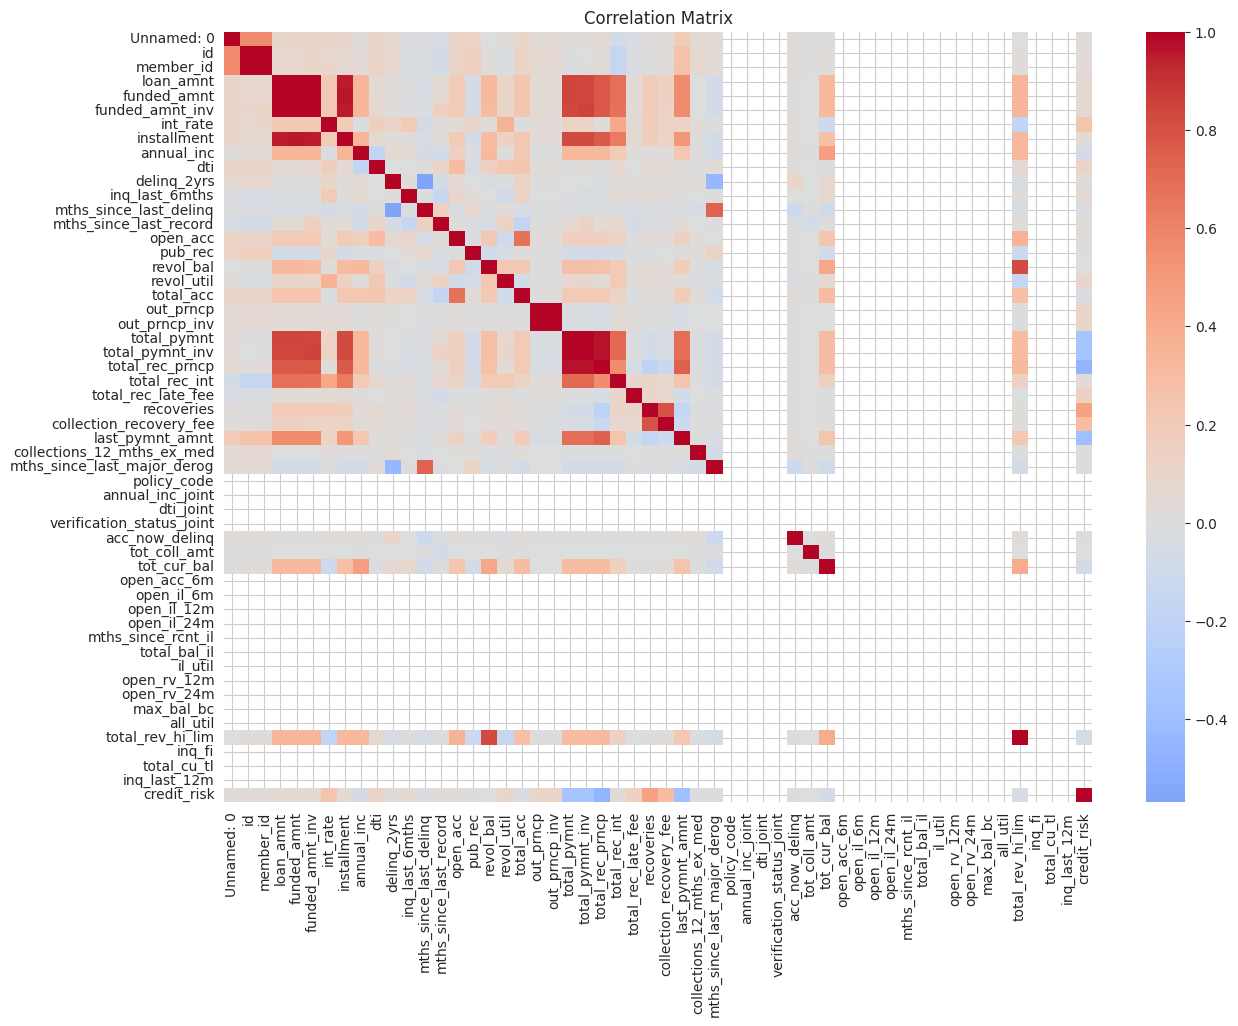

In [48]:
numeric_columns = df_model.select_dtypes(
    include=np.number
).columns

correlation = df_model[
    numeric_columns
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.show()

# 3. Data Preparation

Pada tahap ini data dipersiapkan agar dapat digunakan oleh machine learning model.

Tahapan yang dilakukan:

1. Menentukan feature dan target
2. Menghapus kolom yang tidak diperlukan
3. Membagi data menjadi training dan testing set
4. Menangani missing values
5. Melakukan encoding pada categorical variables
6. Melakukan scaling pada numerical variables

Preprocessing dilakukan setelah train-test split untuk menghindari data leakage.

## 3.1. Define X and y

In [49]:
# Target

y = df_model['credit_risk']

# Menghapus target dari features

X = df_model.drop(
    columns=['credit_risk']
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (230795, 75)
y shape: (230795,)


## 3.2. Remove Columns

In [50]:
# Kolom yang tidak digunakan

drop_columns = [
    'loan_status',
    'id',
    'member_id',
    'url',
    'desc',
    'title',
    'emp_title',
    'zip_code',
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d'
]

# Hanya mengambil kolom yang memang ada

drop_columns = [
    col for col in drop_columns
    if col in X.columns
]

X = X.drop(
    columns=drop_columns
)

print("Jumlah feature setelah selection:", X.shape[1])

Jumlah feature setelah selection: 55


### Feature Selection

Beberapa kolom tidak digunakan dalam modelling karena:

- merupakan identifier
- berupa informasi deskriptif yang sulit digunakan secara langsung
- atau merupakan informasi yang baru diketahui setelah loan berjalan.

Kolom seperti total payment, recoveries, dan last payment tidak digunakan karena berpotensi menyebabkan target leakage. Informasi tersebut merupakan hasil dari performa loan setelah pinjaman diberikan, sedangkan model seharusnya menggunakan informasi yang tersedia pada saat proses penilaian loan.

## 3.3. Train Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (184636, 55)
Testing data : (46159, 55)


## 3.4. Identify Numerical & Categorical

In [52]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 41
Categorical features: 14


## 3.5. Preprocessing

In [53]:
# Numerical preprocessing

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

# Gabungkan preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline berhasil dibuat.")

Preprocessing pipeline berhasil dibuat.


# 4. Data Modelling

Pada tahap ini dua model klasifikasi akan dibangun:

### Logistic Regression

Logistic Regression digunakan karena cocok untuk binary classification dan dapat menjadi baseline model yang mudah diinterpretasikan.

### Random Forest

Random Forest digunakan sebagai model pembanding. Model ini terdiri dari beberapa decision tree sehingga dapat menangkap pola non-linear dalam data.

Kedua model akan dibandingkan menggunakan beberapa evaluation metrics.

## 4.1. Logistic Regression

In [54]:
# Logistic Regression pipeline

logistic_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Training

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression selesai dilatih.")

Logistic Regression selesai dilatih.


## 4.2. Random Forest

In [55]:
# Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=RANDOM_STATE,
                class_weight='balanced',
                n_jobs=-1
            )
        )
    ]
)

# Training

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest selesai dilatih.")

Random Forest selesai dilatih.


## 4.3. Prediction

In [57]:
# Logistic Regression prediction

y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(
    X_test
)[:, 1]


# Random Forest prediction

y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

## 4.4. Cross Validation

In [58]:
# Stratified K-Fold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [59]:
# Logistic Regression
lr_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("Logistic Regression CV ROC-AUC:")
print(lr_cv_scores)

print(
    "Mean:",
    lr_cv_scores.mean()
)

print(
    "Std:",
    lr_cv_scores.std()
)

Logistic Regression CV ROC-AUC:
[0.7415648  0.73957231 0.73609526 0.74064508 0.74267384]
Mean: 0.7401102600284754
Std: 0.0022531453441317554


In [60]:
# Random Forest
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("Random Forest CV ROC-AUC:")
print(rf_cv_scores)

print(
    "Mean:",
    rf_cv_scores.mean()
)

print(
    "Std:",
    rf_cv_scores.std()
)

Random Forest CV ROC-AUC:
[0.723853   0.7197391  0.71509874 0.72105045 0.7225053 ]
Mean: 0.7204493154765378
Std: 0.003010200924731488


# 5. Evaluation

Model akan dievaluasi menggunakan test set yang tidak digunakan dalam proses training.

Metrics yang digunakan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Selain metrics numerik, confusion matrix dan ROC curve juga digunakan untuk melihat performa model secara lebih visual.

## 5.1. Evaluation Function

In [61]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_probability
):

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),
        'Precision': precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'F1-Score': f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            y_true,
            y_probability
        )
    }

## 5.2. Model Comparison

In [62]:
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6602,0.3218,0.7037,0.4416,0.7424
1,Random Forest,0.6538,0.3121,0.6749,0.4268,0.7191


## 5.3. Classification Report: Logistic Regression

In [63]:
print("Classification Report - Logistic Regression")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['GOOD', 'BAD'],
        digits=4
    )
)

Classification Report - Logistic Regression
              precision    recall  f1-score   support

        GOOD     0.9028    0.6500    0.7558     37345
         BAD     0.3218    0.7037    0.4416      8814

    accuracy                         0.6602     46159
   macro avg     0.6123    0.6768    0.5987     46159
weighted avg     0.7919    0.6602    0.6958     46159



## 5.4. Classification Report: Random Forest

In [64]:
print("Classification Report - Random Forest")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['GOOD', 'BAD'],
        digits=4
    )
)

Classification Report - Random Forest
              precision    recall  f1-score   support

        GOOD     0.8943    0.6488    0.7520     37345
         BAD     0.3121    0.6749    0.4268      8814

    accuracy                         0.6538     46159
   macro avg     0.6032    0.6619    0.5894     46159
weighted avg     0.7831    0.6538    0.6899     46159



## 5.5. Confusion Matrix: Logistic Regression

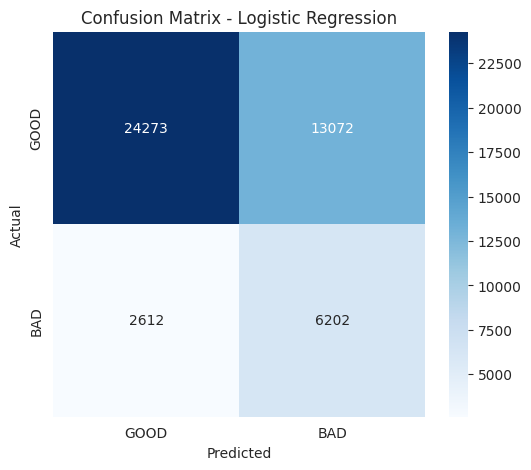

In [65]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['GOOD', 'BAD'],
    yticklabels=['GOOD', 'BAD']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 5.6. Confusion Matrix: Random Forest

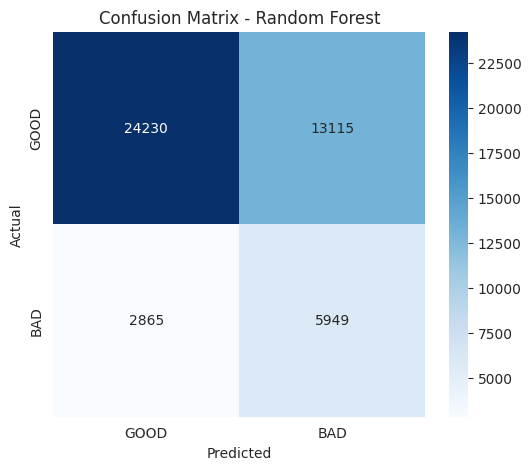

In [66]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['GOOD', 'BAD'],
    yticklabels=['GOOD', 'BAD']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 5.7. ROC Curve

<Figure size 800x600 with 0 Axes>

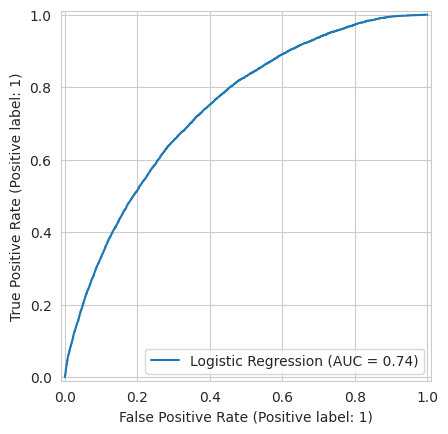

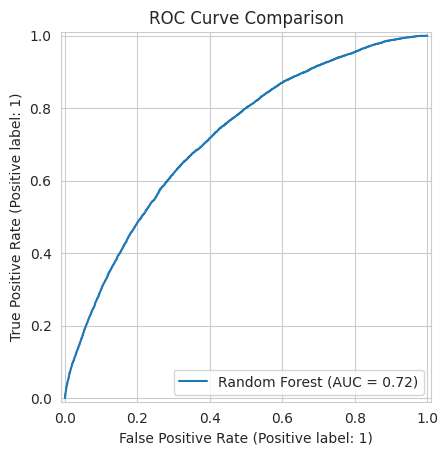

In [67]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest'
)

plt.title('ROC Curve Comparison')

plt.show()

## 5.8. Cross Validation Comparison

In [68]:
cv_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Mean CV ROC-AUC': [
        lr_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    'Std CV ROC-AUC': [
        lr_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

display(
    cv_comparison.round(4)
)

,Model,Mean CV ROC-AUC,Std CV ROC-AUC
0,Logistic Regression,0.7401,0.0023
1,Random Forest,0.7204,0.0030


## 5.9. Final Model

Berdasarkan hasil evaluasi, model akan dipilih dengan mempertimbangkan ROC-AUC, precision, recall, dan F1-score.

ROC-AUC digunakan sebagai salah satu metric utama karena dapat menunjukkan kemampuan model dalam membedakan borrower dengan risiko GOOD dan BAD.

Selain itu, recall juga diperhatikan karena dalam konteks credit risk terdapat risiko ketika borrower yang sebenarnya BAD diprediksi sebagai GOOD.

In [69]:
# Menentukan model dengan ROC-AUC tertinggi

best_model = results_df.loc[
    results_df['ROC-AUC'].idxmax()
]

display(
    best_model.to_frame('Value')
)

,Value
Model,Logistic Regression
Accuracy,0.660218
Precision,0.321781
Recall,0.703653
F1-Score,0.441612
ROC-AUC,0.742405


# 6. Conclusion

## 6.1. Data Understanding

Dataset yang digunakan terdiri dari data historis pinjaman dengan berbagai informasi mengenai borrower dan loan.

Variabel `loan_status` digunakan sebagai dasar untuk membentuk target credit risk.

## 6.2. Exploratory Data Analysis

EDA dilakukan untuk memahami karakteristik borrower dan loan serta melihat pola yang berhubungan dengan credit risk.

Beberapa variabel seperti loan grade, interest rate, loan term, dan karakteristik finansial borrower menunjukkan adanya perbedaan karakteristik antara kelompok GOOD dan BAD.

## 6.3. Data Preparation

Data dipersiapkan melalui:

- penghapusan beberapa kolom yang tidak relevan atau berpotensi menyebabkan leakage
- train-test split
- imputasi missing values
- encoding categorical variables
- scaling numerical variables

Pipeline digunakan agar proses preprocessing dilakukan secara konsisten antara training dan testing data.

## 6.4. Modelling

Dua algoritma digunakan:

1. Logistic Regression
2. Random Forest

Kedua model dibandingkan menggunakan ROC-AUC dan beberapa classification metrics lainnya.

## 6.5. Evaluation

Hasil evaluasi menunjukkan model dengan performa terbaik berdasarkan ROC-AUC adalah model yang dipilih sebagai final model.

Namun, pemilihan model dalam konteks credit risk tidak hanya mempertimbangkan satu metric. Recall terhadap kelas BAD juga perlu diperhatikan karena kesalahan dalam mengidentifikasi borrower berisiko dapat memberikan dampak finansial bagi perusahaan.

## 6.6. Business Recommendation

Model yang telah dibangun dapat digunakan sebagai salah satu alat pendukung dalam proses credit risk assessment.

Model sebaiknya tidak digunakan sebagai satu-satunya dasar keputusan kredit, tetapi dapat dikombinasikan dengan credit policy dan proses evaluasi lainnya.

Untuk pengembangan selanjutnya, model dapat ditingkatkan dengan:

- hyperparameter tuning
- feature engineering yang lebih mendalam
- threshold optimization
- model explainability
- monitoring model performance
- evaluasi menggunakan data periode yang lebih baru